In [2]:
import math
from abc import ABC, abstractmethod
from typing import Optional, List, Type, Tuple, Dict

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from scipy.signal import savgol_filter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Physics Simulation (Allen-Cahn)

In [3]:
def allen_cahn_drift(u, dx, eps):
    """
    Compute Allen-Cahn drift with Neumann boundary conditions: u_x(±1) = 0
    """
    # Interior points: central difference
    u_xx_interior = (torch.roll(u, -1) - 2*u + torch.roll(u, 1)) / (dx*dx)

    # Apply Neumann boundary conditions: u_x = 0 at boundaries
    u_xx = u_xx_interior.clone()

    # At left boundary (x=-1): use forward difference approximation
    u_xx[..., 0] = (2*u[..., 1] - 2*u[..., 0]) / (dx*dx)

    # At right boundary (x=1): use backward difference approximation
    u_xx[..., -1] = (2*u[..., -2] - 2*u[..., -1]) / (dx*dx)

    reaction = -(1/eps**2) * (u**3 - u)
    return u_xx + reaction

def generate_ICs_variable_n(x, n_min=1, n_max=10):
    """
    Generates a single initial condition u0(x) using:
        u0(x) = sin(pi/n * x) * x^2 * (1 - x)^2
    where n is randomly chosen between n_min and n_max.
    """
    n = torch.randint(n_min, n_max + 1, (1,)).item()
    amp = torch.rand(1).item() * 1.5 + 0.5  # between 0.5 and 2
    u0 = amp * torch.sin((math.pi / n) * x)
    return u0

class ODE(ABC):
    @abstractmethod
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        pass

class AllenCahnODE(ODE):
    def __init__(self, dx: float, eps: float):
        super().__init__()
        self.dx = dx
        self.eps = eps

    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        return allen_cahn_drift(xt, self.dx, self.eps)

class Simulator(ABC):
    @abstractmethod
    def step(self, xt: torch.Tensor, t: torch.Tensor, dt: torch.Tensor):
        pass

    @torch.no_grad()
    def simulate(self, x: torch.Tensor, ts: torch.Tensor):
        # assumir ts com shape (1, num_steps+1, 1)
        nts = ts.shape[1]
        for t_idx in range(nts - 1):
            t = ts[:, t_idx]
            h = ts[:, t_idx + 1] - ts[:, t_idx]
            x = self.step(x, t, h)
        return x

    @torch.no_grad()
    def simulate_with_trajectory(self, x: torch.Tensor, ts: torch.Tensor):
        xs = [x.clone()]
        nts = ts.shape[1]
        for t_idx in tqdm(range(nts - 1), desc="Simulating trajectory"):
            t = ts[:,t_idx]
            h = ts[:, t_idx + 1] - ts[:, t_idx]
            x = self.step(x, t, h)
            xs.append(x.clone())
        return torch.stack(xs, dim=1)

class EulerSimulator(Simulator):
    def __init__(self, ode: ODE):
        self.ode = ode

    def step(self, xt: torch.Tensor, t: torch.Tensor, h: torch.Tensor):
        return xt + self.ode.drift_coefficient(xt,t) * h

## 2. Dataset (Normalized & Epsilon-Aware)

In [12]:
class Sampleable(ABC):
    @property
    @abstractmethod
    def dim(self) -> int:
        pass
    @abstractmethod
    def sample(self, num_samples: int) -> torch.Tensor:
        pass

class AllenCahnDataset(torch.nn.Module, Sampleable):
    def __init__(
        self,
        N: int,
        eps_min: float = 0.02,  # <--- CHANGED: Increased from 1e-4 to 0.02 for stability
        eps_max: float = 1.0,
        num_epsilons: int = 100,
        T: float = 0.02,         # <--- CHANGED: Reduced T slightly to speed up generation
        dt: float = 1e-5,
        device=device,
        n_min=1,
        n_max=3
    ):
        super().__init__()
        self.N = N
        self.device = device

        self.T = T
        self.dt = dt

        # spatial grid
        x = torch.linspace(-1, 1, N, device=device)
        self.dx = (x[1] - x[0]).item()
        self.x = x

        # epsilon values
        self.epsilons = torch.logspace(
            math.log10(eps_min),
            math.log10(eps_max),
            steps=num_epsilons,
            device=device
        )

        # time discretization
        num_steps = int(T / dt)
        ts = torch.linspace(0, T, num_steps + 1, device=device).view(1, -1, 1)

        samples = []
        print(f"Generating Allen–Cahn dataset (eps range: {eps_min} - {eps_max})...")

        for eps in tqdm(self.epsilons):
            # --- variable IC
            u0 = generate_ICs_variable_n(x, n_min, n_max).unsqueeze(0)
            # --- build ODE
            ode = AllenCahnODE(self.dx, eps.item())
            # --- simulate
            simulator = EulerSimulator(ode)
            uT = simulator.simulate(u0, ts)  # shape (1, N)
            samples.append(uT.squeeze(0))

        raw_data = torch.stack(samples, dim=0)

        # --- Normalize Data ---
        self.mean = raw_data.mean()
        self.std = raw_data.std()
        self.register_buffer("data", (raw_data - self.mean) / self.std)
        print(f"Dataset normalized. Mean: {self.mean:.4f}, Std: {self.std:.4f}")

    @property
    def dim(self) -> int:
        return self.N

    def sample(self, num_samples: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """Returns (normalized_field, epsilon)"""
        idx = torch.randint(0, self.data.shape[0], (num_samples,), device=self.device)
        return self.data[idx], self.epsilons[idx].view(-1, 1)

## 3. Optimal Transport Path & 1D CNN Model

In [ ]:
def sample_x0_fourier_mix(batch_size, x, device, n_modes=8):
    """
    Generates Gaussian like intial conditions with random mean and sigma
    for each batch element.

    returns: (batch_size, N)
    """
    x = x.to(device)
    if x.ndim > 1:
        x_flat = x.view(-1)
    else:
        x_flat = x
    # shape (1, N) para broadcast
    x_grid = x_flat.view(1, -1)

    B = batch_size

    # médias ~ Uniform(-0.5, 0.5)  (podes ajustar o intervalo)
    mu = torch.empty(B, 1, device=device).uniform_(-0.5, 0.5)

    # sigma > 0; uso log-uniform entre 0.15 e 0.6, por ex.
    log_sigma_min = math.log(0.15)
    log_sigma_max = math.log(0.6)
    log_sigma = torch.empty(B, 1, device=device).uniform_(log_sigma_min, log_sigma_max)
    sigma = log_sigma.exp()

    # Gaussiana  exp(-(x-mu)^2 / (2 sigma^2)) -> shape (B, N)
    u0 = 0.2 * torch.exp(-((x_grid - mu) ** 2) / (2.0 * sigma ** 2))

    # opcional: dar amplitude aleatória ou normalizar
    # amp = torch.empty(B, 1, device=device).uniform_(0.7, 1.3)
    # u0 = amp * u0

    # opcional: normalizar para [-1, 1] aproximadamente
    # u0 = u0 / (u0.abs().max(dim=1, keepdim=True)[0] + 1e-8)

    return u0


# --- 1. Optimal Transport Path ---
class OptimalTransportPath(torch.nn.Module):
    def __init__(self, p_data: AllenCahnDataset):
        super().__init__()
        self.p_data = p_data

    def sample_batch(self, batch_size: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Returns:
            xt: Interpolated state (B, dim)
            t: Time (B, 1)
            eps: Epsilon condition (B, 1)
            ut: Target vector field (B, dim)
        """
        # 1. Get data (x1) and condition (eps)
        x1, eps = self.p_data.sample(batch_size)

        # 2. Sample Noise (x0)
        #x0 = torch.randn_like(x1)
        x0 = sample_x0_fourier_mix(batch_size, self.p_data.x, x1.device)


        # 3. Sample Time (t)
        t = torch.rand((batch_size, 1), device=x1.device)

        # 4. Interpolate (OT path: straight line)
        # x_t = (1 - t) * x0 + t * x1
        xt = (1 - t) * x0 + t * x1

        # 5. Target Vector Field (u_t = x1 - x0)
        ut = x1 - x0

        return xt, t, eps, ut

# --- 2. 1D CNN Vector Field (Spatial Bias) ---
class Conv1DVectorField(torch.nn.Module):
    def __init__(self, dim: int):
        super().__init__()

        # We will concatenate x, t, and eps as channels
        # Input channels = 1 (x) + 1 (t) + 1 (eps) = 3
        self.down1 = torch.nn.Conv1d(3, 64, kernel_size=7, padding=3) # Larger kernel
        self.down2 = torch.nn.Conv1d(64, 128, kernel_size=7, padding=3)
        self.mid   = torch.nn.Conv1d(128, 128, kernel_size=7, padding=3)
        self.up1   = torch.nn.Conv1d(128, 64, kernel_size=7, padding=3)
        self.out   = torch.nn.Conv1d(64, 1, kernel_size=7, padding=3)

        self.act = torch.nn.SiLU()

    def forward(self, x, t, eps):
        # x: (B, 200)
        # t: (B, 1)
        # eps: (B, 1)

        B, N = x.shape

        # 1. Prepare inputs as channels
        x_map = x.unsqueeze(1) # (B, 1, N)

        t_map = t.unsqueeze(-1).expand(B, 1, N) # (B, 1, N)

        # Log-scale epsilon for easier learning
        eps_log = torch.log10(eps + 1e-8)
        eps_map = eps_log.unsqueeze(-1).expand(B, 1, N) # (B, 1, N)

        # Concatenate: (B, 3, N)
        h = torch.cat([x_map, t_map, eps_map], dim=1)

        # 2. Forward Pass
        h1 = self.act(self.down1(h))   # (B, 64, N)
        h2 = self.act(self.down2(h1))  # (B, 128, N)
        h_mid = self.act(self.mid(h2)) # (B, 128, N)

        h3 = self.act(self.up1(h_mid)) # (B, 64, N)
        h3 = h3 + h1 # Skip connection

        out = self.out(h3) # (B, 1, N)
        return out.squeeze(1)

In [6]:
def allen_cahn_residual(model, x, t, eps):
    t.requires_grad_(True)
    x.requires_grad_(True)
    u = model(x, t, eps)

    # u_t
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u),
                              create_graph=True)[0]

    # u_x
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),
                              create_graph=True)[0]

    # u_xx
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u),
                               create_graph=True)[0]

    # Allen–Cahn residual
    f = u**3 - u
    r = u_t - eps**2 * u_xx + f
    return r


In [ ]:
def compute_boundary_loss(model, t, eps, device, N_spatial=200):
    """
    Neumann BC: u_x(±1, t) = 0
    Aplica a BC para um batch de tempos t e eps (mesmo shape do treino).

    Args:
        model : rede u_theta(x_field, t, eps)
        t     : (B, 1)
        eps   : (B, 1)
        device: torch.device
        N_spatial : número de pontos em x (igual ao do flow)
    """
    B = t.shape[0]
    x = torch.linspace(-1.0, 1.0, N_spatial, device=device)
    dx = x[1] - x[0]

    # campos "falsos" só para impor BC: ruído em x
    X_BC = torch.randn(B, N_spatial, device=device)

    # u(x, t, eps) que queremos que respeite BC
    u = model(X_BC, t, eps)  # (B, N_spatial)

    # derivada espacial nas fronteiras (diferença finita 1ª ordem)
    u_x_left  = (u[:, 1]  - u[:, 0])   / dx  # x = -1
    u_x_right = (u[:, -1] - u[:, -2]) / dx   # x =  1

    loss_BC = torch.mean(u_x_left*2 + u_x_right*2)
    return loss_BC

## 4. Training Loop

In [14]:
class Trainer(ABC):
    def __init__(self, model: torch.nn.Module):
        super().__init__()
        self.model = model

    @abstractmethod
    def get_train_loss(self, **kwargs) -> torch.Tensor:
        pass

    def get_optimizer(self, lr: float):
        return torch.optim.Adam(self.model.parameters(), lr=lr)

    def train(self, num_epochs: int, device: torch.device, lr: float = 1e-3, batch_size: int = 128):
        self.model.to(device)
        opt = self.get_optimizer(lr)
        self.model.train()

        loss_history = []

        pbar = tqdm(range(num_epochs))
        for epoch in pbar:
            opt.zero_grad()
            loss = self.get_train_loss(batch_size=batch_size)
            loss.backward()
            opt.step()

            loss_history.append(loss.item())
            pbar.set_description(f"Epoch {epoch} | Loss={loss.item():.4f}")

        self.model.eval()
        return loss_history

class OTFlowMatchingTrainer(Trainer):
    def __init__(self, path: OptimalTransportPath, model: torch.nn.Module):
        super().__init__(model)
        self.path = path

    def get_train_loss(self, batch_size: int) -> torch.Tensor:
        # Sample batch from OT path

        xt, t, eps, u_star = self.path.sample_batch(batch_size)

        # Predict vector field
        u_theta = self.model(xt, t, eps)

        loss_fm = ((u_theta - u_star)**2).mean()

        r = allen_cahn_residual(self.model, xt, t, eps)
        loss_pde = torch.mean(r**2)

        # loss_ic = torch.mean((self.model(x_ic, t0) - u0(x_ic))**2)

        # loss_bc = torch.mean((self.model(x_left, t) - bc_left)**2) \
        # + torch.mean((self.model(x_right, t) - bc_right)**2)


        w_pde = 0.1  # Weight for PDE loss

        loss = loss_fm + w_pde * loss_pde


        return loss

Generating Allen–Cahn dataset (eps range: 0.02 - 1.0)...


100%|██████████| 100/100 [00:42<00:00,  2.35it/s]


Dataset normalized. Mean: -0.0000, Std: 0.8553


Epoch 999 | Loss=0.1686: 100%|██████████| 1000/1000 [1:34:37<00:00,  5.68s/it]


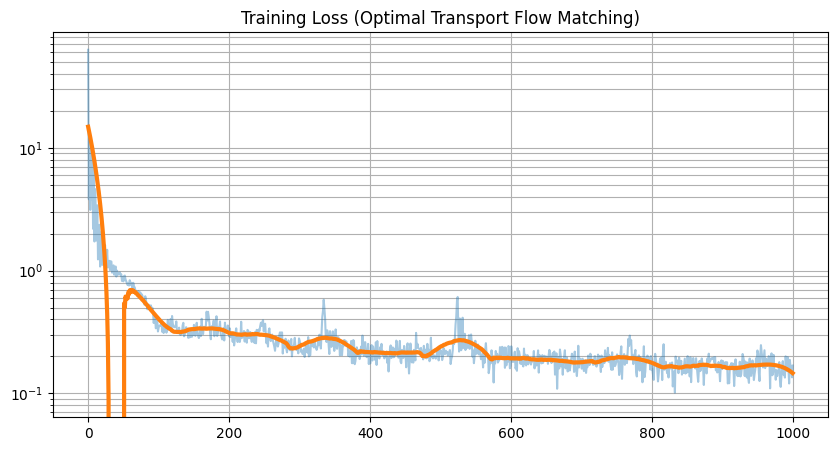

In [9]:
# ---- p_data: Allen–Cahn final fields in R^N ----
p_data = AllenCahnDataset(
    N=200,
    eps_min=0.02,
    eps_max=1.0,
    num_epsilons=100, # More epsilons for better generalization
    T=0.02,
    dt=1e-5,
    device=device,
    n_min=2,
    n_max=3
).to(device)

# ---- OT Path ----
path = OptimalTransportPath(p_data).to(device)

# ---- 1D CNN Vector Field ----
flow_model = Conv1DVectorField(dim=p_data.dim).to(device)

# ---- Trainer ----
trainer = OTFlowMatchingTrainer(path, flow_model)

# ---- Train ----
losses = trainer.train(
    num_epochs = 1000,
    device = device,
    lr = 1e-3, # CNNs can often take higher LR
    batch_size = 128
)

# ---- Plot Loss ----
plt.figure(figsize=(10,5))
plt.plot(losses, label="Loss", alpha=0.4)
plt.plot(savgol_filter(losses, 101, 3), label="Trend", linewidth=3)
plt.title("Training Loss (Optimal Transport Flow Matching)")
plt.yscale('log')
plt.grid(True, which="both", ls="-")
plt.show()

## 5. Sampling & Visualization

Simulating trajectory: 100%|██████████| 99/99 [00:01<00:00, 68.89it/s]


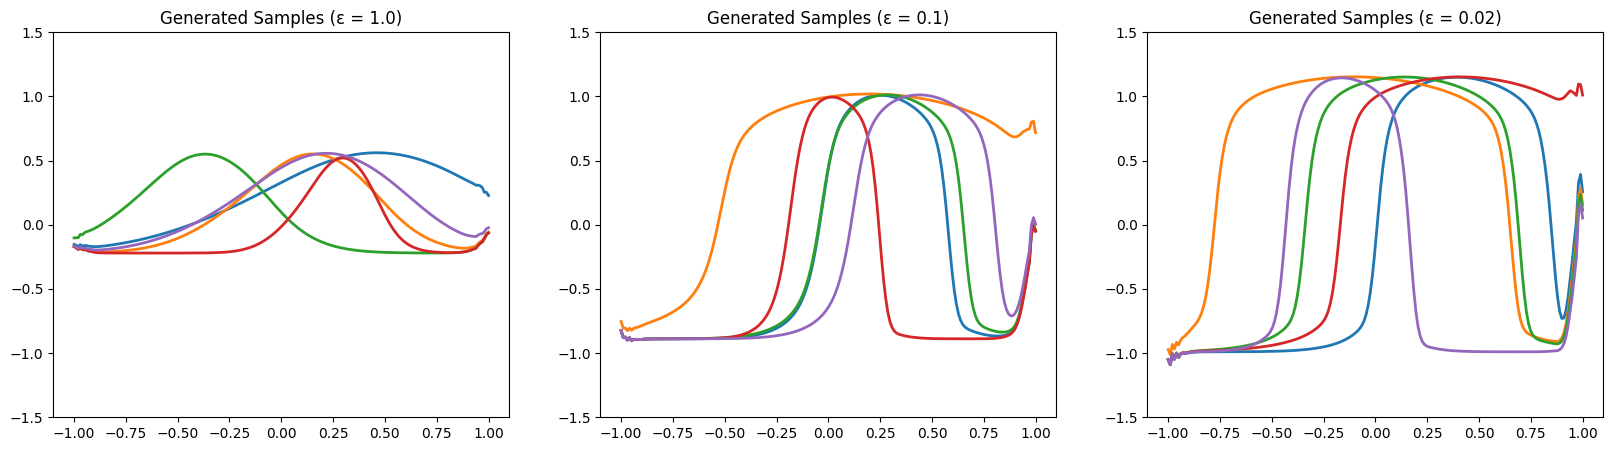

In [10]:
class LearnedVectorFieldODE(ODE):
    def __init__(self, net, eps_val):
        self.net = net
        self.eps_val = eps_val

    def drift_coefficient(self, x, t):
        bs = x.shape[0]
        # Create a batch of the specific epsilon value we want
        eps_batch = torch.tensor([self.eps_val], device=x.device).expand(bs, 1)
        return self.net(x, t, eps_batch)

# ==========================================
# Compare Generated Samples for Different Epsilons
# ==========================================
eps_to_test = [1.0, 0.1, 0.02] # Diffuse -> Sharp -> Very Sharp
num_samples = 5
ts = torch.linspace(0.0, 1.0, 100, device=device).view(1, -1, 1).expand(num_samples, -1, 1)
x_grid = p_data.x.cpu()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, eps_val in enumerate(eps_to_test):
    # 1. Setup ODE with specific epsilon
    ode = LearnedVectorFieldODE(flow_model, eps_val)
    simulator = EulerSimulator(ode)

    # 2. Sample Noise
    #x0 = torch.randn(num_samples, p_data.dim, device=device)
    x0 = sample_x0_fourier_mix(num_samples, p_data.x, device)


    # 3. Simulate
    xts = simulator.simulate_with_trajectory(x0, ts)

    # 4. Plot Final States (Un-normalized)
    final_samples = xts[:, -1, :].detach().cpu() * p_data.std.cpu() + p_data.mean.cpu()

    axes[i].set_title(f"Generated Samples (ε = {eps_val})")
    axes[i].set_ylim(-1.5, 1.5)
    for j in range(num_samples):
        axes[i].plot(x_grid, final_samples[j], linewidth=2)

plt.show()

Simulating trajectory: 100%|██████████| 99/99 [00:00<00:00, 168.59it/s]


Generating Ground Truth samples for comparison...


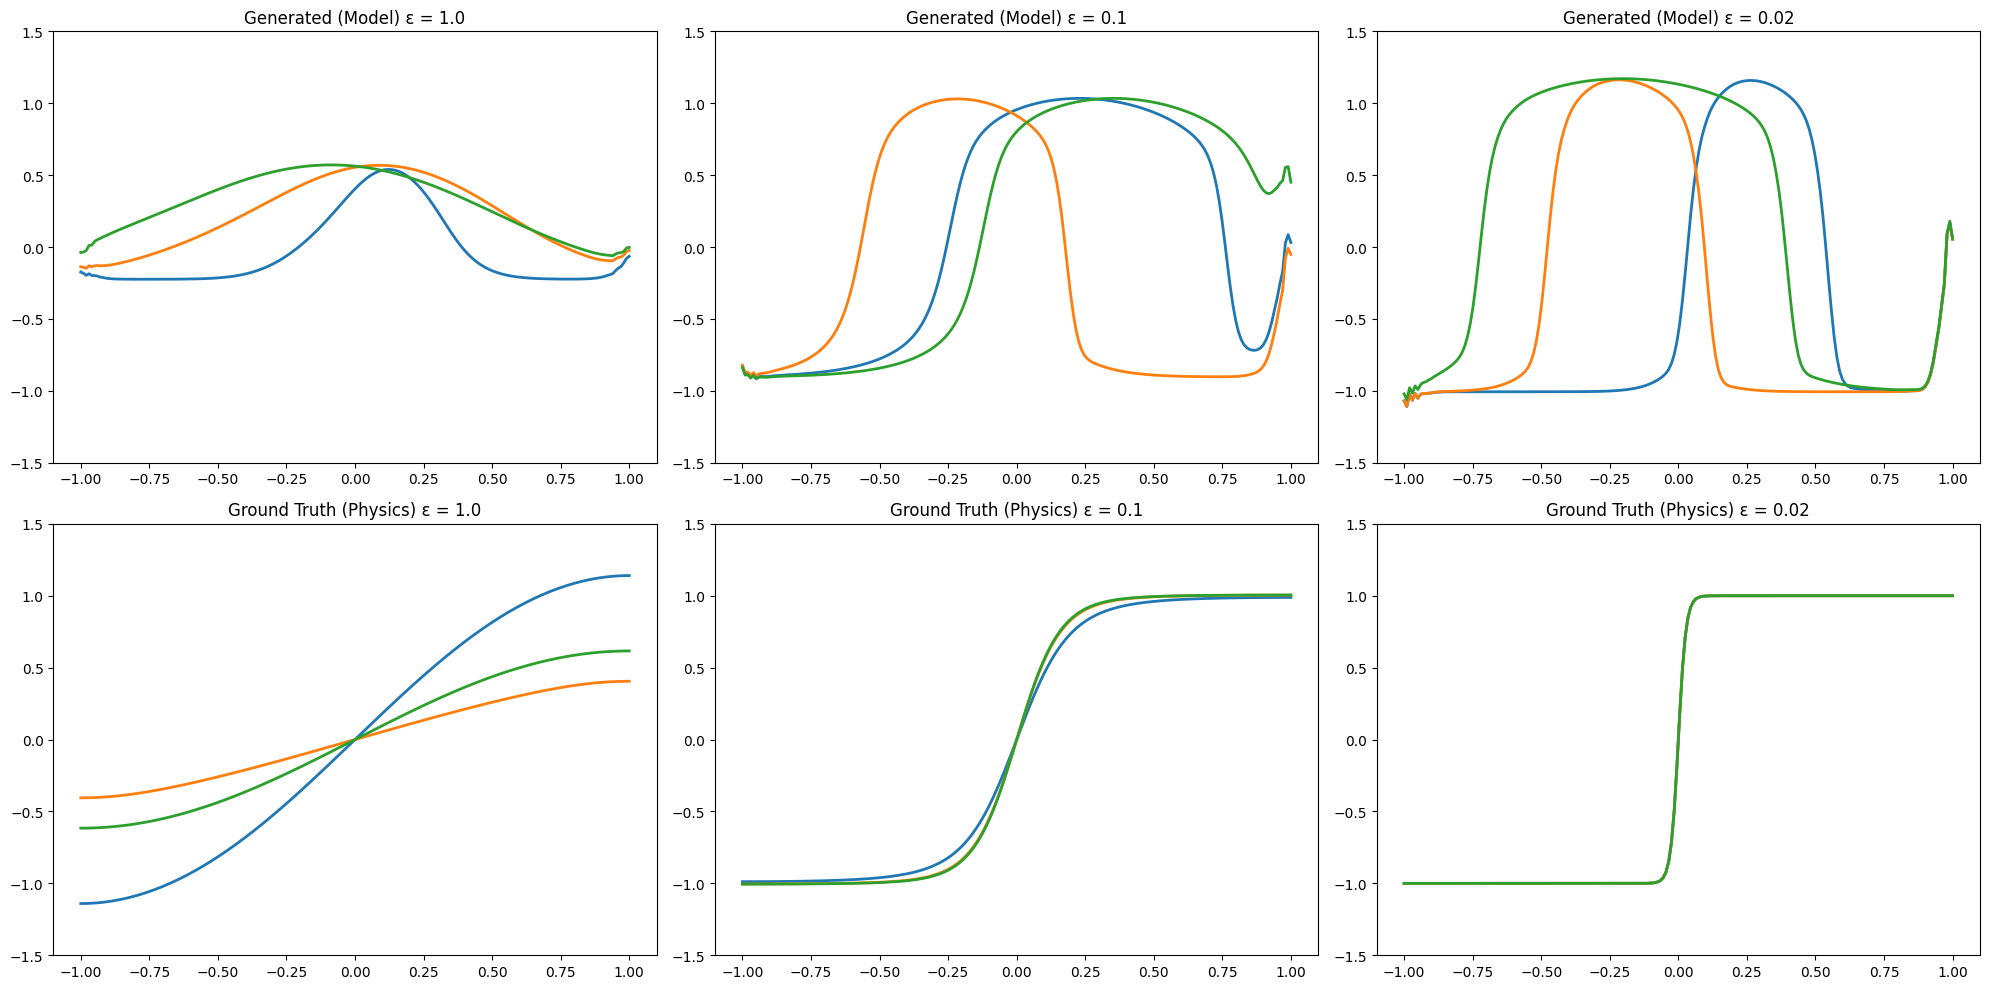

In [16]:
# ==========================================
# Compare Generated Samples vs Ground Truth
# ==========================================
eps_to_test = [1.0, 0.1, 0.02]
num_samples = 3
ts = torch.linspace(0.0, 1.0, 100, device=device).view(1, -1, 1).expand(num_samples, -1, 1)
x_grid = p_data.x.cpu()

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Row 1: Generated Samples
for i, eps_val in enumerate(eps_to_test):
    # 1. Setup ODE with specific epsilon
    ode = LearnedVectorFieldODE(flow_model, eps_val)
    simulator = EulerSimulator(ode)

    # 2. Sample Noise
   # x0 = torch.randn(num_samples, p_data.dim, device=device)
    x0 = sample_x0_fourier_mix(num_samples, p_data.x, device)


    # 3. Simulate
    xts = simulator.simulate_with_trajectory(x0, ts)

    # 4. Plot Final States (Un-normalized)
    final_samples = xts[:, -1, :].detach().cpu() * p_data.std.cpu() + p_data.mean.cpu()

    axes[0, i].set_title(f"Generated (Model) ε = {eps_val}")
    axes[0, i].set_ylim(-1.5, 1.5)
    for j in range(num_samples):
        axes[0, i].plot(x_grid, final_samples[j], linewidth=2)

# Row 2: Ground Truth Samples
print("Generating Ground Truth samples for comparison...")
for i, eps_val in enumerate(eps_to_test):
    axes[1, i].set_title(f"Ground Truth (Physics) ε = {eps_val}")
    axes[1, i].set_ylim(-1.5, 1.5)

    # Generate fresh ground truth samples for this specific epsilon
    for j in range(num_samples):
        # Use the same physics generation code as the dataset
        u0 = generate_ICs_variable_n(p_data.x, n_min=2, n_max=3).unsqueeze(0)
        ode = AllenCahnODE(p_data.dx, eps_val)
        simulator = EulerSimulator(ode)

        # Simulate physics
        # Note: We use the same T and dt as training
        ts_physics = torch.linspace(0, p_data.T, int(p_data.T / p_data.dt) + 1, device=device).view(1, -1, 1)

        uT = simulator.simulate(u0, ts_physics)

        axes[1, i].plot(x_grid, uT.squeeze().cpu(), linewidth=2)

plt.tight_layout()
plt.show()